# Kaggle Playground Competition Season 6 - Episode 8: Predicting Smartphone Addiction
This notebook covers an end-to-end approach for [Kaggle's August 2026 playground competition](https://www.kaggle.com/competitions/playground-series-s6e8/), **Predicting Smartphone Addiction**. My personal goal with this competition, as per usual, is to keep my own data science skills sharp and perhaps some new things along the way. In full transparency, I am using ChatGPT to help me as a **thought partner**, NOT as an "end-to-end solver". (No Codex / Claude Code being used here!) Even in this case, I have zero expectation of winning this competition, and I'm completely fine with that!

This being a Kaggle playground competition, the dataset supporting this competition is one synthesized based on real dataset using the same raw data features. As the competition name implies, we are attempting to predict smartphone addiction as a **binary classification problem**: either the person is addicted or is not addicted. We will do a deeper dive analysis of the supporting data in the Exploratory Data Analysis section.

## 0: Notebook Setup
Let's set ourselves up for success by doing all the necessary "administrative overhead" for our work!

In [1]:
# Importing the necessary Python libraries
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Setting the seaborn color palette
sns.set_palette('pastel')

In [3]:
# Loading in the raw data
df_train_raw = pd.read_csv('data/raw/train.csv')
df_test_raw = pd.read_csv('data/raw/test.csv')

## 1: Exploratory Data Analysis
Let's jump into our notebook by performing an **exploratory data analysis**. We are going to approach this from two perspectives. First, we're going to get a semantic understanding. As you'll see looking at the dataset, it's hard to get an understanding of what we're working with solely based on the raw feature (column) names. We'll use Kaggle's platform to help us get a better understanding of the data at a semantic level. Second, we're going to do a deep dive data analysis, which also includes some statistical analyses. By doing this analysis from both of these perspectives, we will gain a robust understanding of the data we are working with and start to strategize on how feature engineering might start to take form.

### 1.1: Understanding the data at a semantic level
As we noted at the top of the notebook, Kaggle's playground competitions are comprised of datasets that are synthesized based on other datasets, so generally speaking, Kaggle doesn't restate what the data is and instead points to the data it was originally sourced from. As of August 1, 2026, it looks like Kaggle mistakenly shared a bad link, meaning that we don't actually have a way to truly determine which dataset this playground competition dataset is sourced from. In combing the discussion board, it appears that this playground dataset is originally sourced from [this dataset](https://www.kaggle.com/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction/data). Unfortunately, not even this dataset covers everything. Specifically, it does not cover `stress_level` nor `academic_work_impact`, so we're going to have to make an informative guess as to what those mean.

Let's get the semantic understanding for each of these respective data features.

- `id`: The unique identifier for each record assigned by Kaggle. (It is not important to the semantic understanding of the overall dataset, and we will not use it when constructing the final model.)
- `age`: The age of the user. Range is 18-35 years old.
- `daily_screen_time_hours`: The average number of hours a user spends on their smartphone each day.
- `social_media_hours`: The average number of hours a user spends on social media each day.
- `gaming_hours`: The average number of hours a user plays mobile games on their smartphone each day.
- `work_study_hours`: The average number of hours a user is productive throughout the day, whether that be actively working or studying. 
- `sleep_hours`: The average number of hours a user sleeps each day.
- `notifications_per_day`: The number of notifications received daily. 
- `app_opens_per_day`: The number apps open daily.
- `weekend_screen_time`: The average amount of hours a user is on their smartphone on the weekend.
- `gender`: The gender the user idenitifies as. There are three categories present in the dataset: "Male", "Female", and "Other".
- `stress_level`: The stress level the user identifies with. There are three categories present in the dataset: "Low", "Medium", and "High".
- `academic_work_impact`: The impact a user experiences based on academic work. This is a boolean "Yes" or "No" field.
- `addicted_label`: The target variable represented by a binary 1 or 0. 1 = yes, the user is addicted; 0 = no, the user is not addicted.

A few general notes about these data elements:
- There are a number of times where the word "average" is used. It is unclear what they mean by that, so I'm going to assume it's the mean average.
- There are a couple features like `notifications_per_day` where all the data records are represented by integer values. The reason I find this curious is because this almost certainly can't represent a mean average values since means are rarely integers, especially when all the records are integers. I'm not sure what to think about this, so we're just going to assume it's something close to a mean average.
- As noted above, those last two features I could not find present in other potential datasets this playground dataset what synthesized on. `stress_level` seemed pretty self explanatory, but I am really not sure what `academic_work_impact` means. Not sure if this means that the user is focused on academic work in a positive or negative way. By positive, I mean that the user is positively using their smartphone for research purposes. By negative, I mean that the user may be using their smartphone as an "escape" to relax or procrastinate from their academic work. I don't know! We're just going to have to roll with what it is.

### 1.2: High Level Analysis
Now that we have a semantic understanding, let's start by performing a high level analysis on the data.

In [4]:
# Randomly sampling 10 records from the raw training dataset
df_train_raw.sample(n = 10)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
646390,646390,23.0,7.93,2.42,2.81,2.21,5.37,37.0,125.0,11.02,Other,High,Yes,1
431891,431891,34.0,2.66,0.37,0.86,1.22,4.75,NaN,17.0,4.48,Female,High,No,0
242185,242185,26.0,11.02,2.07,0.53,5.84,5.16,194.0,23.0,12.44,Female,Low,Yes,1
298550,298550,24.0,5.73,4.46,0.11,0.79,8.78,228.0,NaN,8.20,Other,Medium,NaN,1
310589,310589,35.0,6.69,2.20,1.64,2.23,5.79,186.0,55.0,8.76,Female,Medium,No,1
676380,676380,22.0,6.61,2.22,1.56,2.35,7.98,132.0,93.0,NaN,Male,High,No,0
562037,562037,24.0,9.17,4.73,0.08,1.35,7.47,175.0,97.0,10.01,Other,NaN,No,1
119311,119311,23.0,6.12,2.15,1.92,1.16,5.28,197.0,NaN,6.75,Other,Low,Yes,0
573188,573188,18.0,6.88,1.31,2.09,2.80,6.67,114.0,41.0,10.21,Male,High,Yes,0
163444,163444,NaN,9.94,4.36,NaN,3.46,6.43,153.0,137.0,8.34,NaN,Low,Yes,1


In [5]:
# Viewing the general statistics around the raw training dataset
df_train_raw.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [6]:
# Viewing general info about the raw training dataset
df_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

### 1.3: Target Variable Analysis

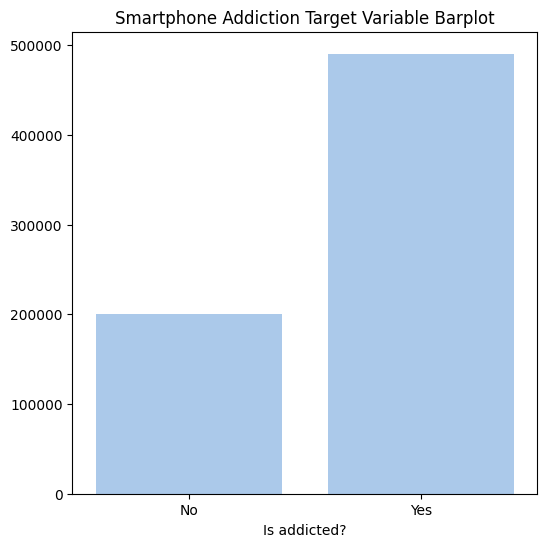

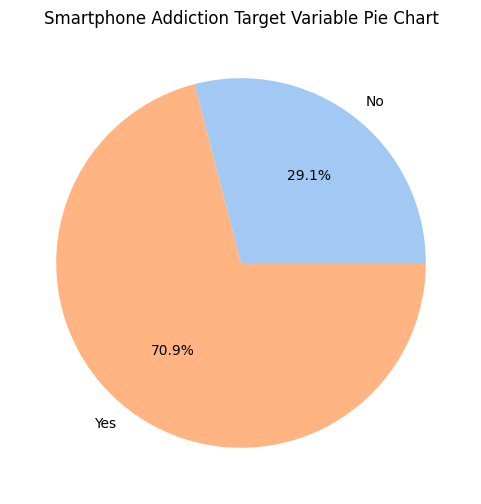

In [7]:
# Getting the counts associated to the target variable
addicted_labels = (
    df_train_raw \
        .groupby('addicted_label') \
        .size() \
        .reset_index(name = 'count')
)

# Converting the values of the target variable for easier understanding
addicted_labels['addicted_label'] = addicted_labels['addicted_label'].map({1: 'Yes', 0: 'No'})

# Creating a bar plot around the target variable
fig, ax = plt.subplots(figsize = (6, 6))
ax = sns.barplot(addicted_labels, x = 'addicted_label', y = 'count');
ax.set_title('Smartphone Addiction Target Variable Barplot');
ax.set_xlabel('Is addicted?')
ax.set_ylabel('')

# Creating a pie chart around the target variable
fig, ax = plt.subplots(figsize = (6, 6))
ax.pie(
    addicted_labels['count'],
    labels = addicted_labels['addicted_label'],
    autopct = '%1.1f%%'
);
ax.set_title('Smartphone Addiction Target Variable Pie Chart');

### 1.4: Univariate and Target-Feature Analysis

#### 1.4.1: Univariate and Target-Feature Helpers

In [8]:
def perform_univariate_numerical_feat_analysis(df, numerical_feat, target_feat):
    '''
    Performs a univariate analysis on a numerical feature and also performs a target-feature analysis

    Inputs:
        - df (Pandas dataframe): The input Pandas DataFrame
        - numerical_feat (str): Name of the numerical feature to be analyzed
        - target_feat (str): Name of the target feature
    '''
    return None

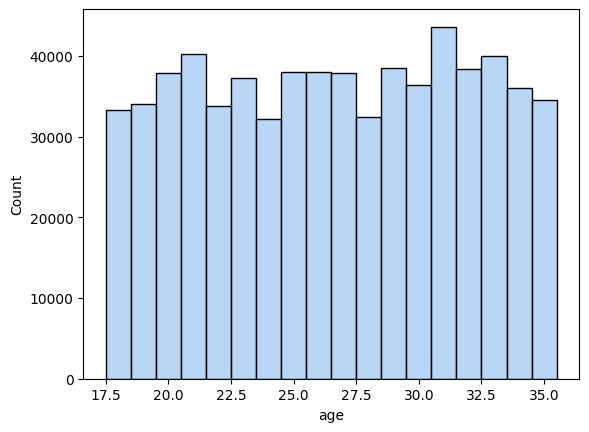

In [9]:
ages = df_train_raw['age'].dropna()
bins = np.arange(ages.min(), ages.max() + 2) - 0.5
sns.histplot(data = df_train_raw, x = 'age', bins = bins);

In [10]:
print(f'Skewness: {df_train_raw['age'].skew()}')
print(f'Kurtosis: {df_train_raw['age'].kurt()}')

Skewness: -0.036801130292778844
Kurtosis: -1.217350888456876
